In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             f1_score, accuracy_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import shap

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#1B4F8A', '#2E75B6', '#5BA3E0', '#A8CBEE', '#D6E8F7']
sns.set_palette(PALETTE)

# ── Config ───────────────────────────────────────────────────────────────────
DATA_PATH = 'ed2022-stata.dta'   # ← update if file is elsewhere
RANDOM_STATE = 42
print("✅ Imports OK")

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/vani/miniforge3/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: '@rpath/libomp.dylib'\n  Referenced from: '/Users/vani/miniforge3/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib'\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/Users/vani/miniforge3/lib/python3.12/lib-dynload/../../libomp.dylib' (no such file), '/Users/vani/miniforge3/bin/../lib/libomp.dylib' (no such file), '/usr/local/lib/libomp.dylib' (no such file), '/usr/lib/libomp.dylib' (

In [3]:
df_raw = pd.read_stata(DATA_PATH, convert_categoricals=False)
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

Shape: 16,025 rows × 913 columns


,VMONTH,VDAYR,ARRTIME,WAITTIME,LOV,AGE,AGER,AGEDAYS,RESIDNCE,SEX,...,RX30V3C2,RX30V3C3,RX30V3C4,SETTYPE,YEAR,CSTRATM,CPSUM,PATWT,EDWT,BOARDED
0,9,2,0604,10,228,23,2,-7,1,1,...,,,,3,2022,20122201,100001,3665.56958,8.36413,-7
1,9,2,1053,40,319,15,2,-7,1,2,...,,,,3,2022,20122201,100001,3665.56958,NaN,-7
2,9,2,1419,70,551,19,2,-7,1,2,...,,,,3,2022,20122201,100001,3665.56958,NaN,-7


In [ ]:
# Key columns we care about — verify they exist
KEY_COLS = {
    'WAITTIME':  'Wait time (minutes) from arrival to seeing provider',
    'IMMEDR':    'Triage immediacy level (1=Immediate, 2=Emergent, 3=Urgent, 4=Semi-urgent, 5=Non-urgent)',
    'AGE':       'Patient age in years',
    'SEX':       'Patient sex (1=Female, 2=Male)',
    'RACERETH':  'Race/ethnicity',
    'ARRTIME':   'Arrival time (military hours)',
    'DAY':    'Arrival day of week',
    'VMONTH':    'Visit month',
    'PULSE':     'Pulse rate (bpm)',
    'TEMPF':     'Temperature (Fahrenheit)',
    'BPSYS':     'Systolic BP',
    'BPDIAS':    'Diastolic BP',
    'RESPR':     'Respiratory rate',
    'PAINSCALE': 'Pain scale (0–10)',
    'SEEN72':    'Seen within 72 hours for same condition',
    'INJURY':    'Injury-related visit',
    'DIAG1':     'Primary diagnosis code',
}

present = {k: v for k, v in KEY_COLS.items() if k in df_raw.columns}
missing = [k for k in KEY_COLS if k not in df_raw.columns]

print(f"✅ Found {len(present)}/{len(KEY_COLS)} key columns")
if missing:
    print(f"⚠️  Missing columns (may differ by year): {missing}")

pd.DataFrame({'Column': list(present.keys()), 'Description': list(present.values())})


✅ Found 16/17 key columns
⚠️  Missing columns (may differ by year): ['ARRDAY']


,Column,Description
0,WAITTIME,Wait time (minutes) from arrival to seeing pro...
1,IMMEDR,"Triage immediacy level (1=Immediate, 2=Emergen..."
2,AGE,Patient age in years
3,SEX,"Patient sex (1=Female, 2=Male)"
4,RACERETH,Race/ethnicity
5,ARRTIME,Arrival time (military hours)
6,VMONTH,Visit month
7,PULSE,Pulse rate (bpm)
8,TEMPF,Temperature (Fahrenheit)
9,BPSYS,Systolic BP


In [5]:
# ── Sentinel → NaN mapping (from NHAMCS codebook) ──────────────────────────
SENTINEL_MAP = {
    'WAITTIME':  [999],
    'AGE':       [93, 99],
    'PULSE':     [997, 999],
    'TEMPF':     [997, 999],
    'BPSYS':     [997, 999],
    'BPDIAS':    [997, 999],
    'RESPR':     [97, 99],
    'PAINSCALE': [98, 99],
}

df = df_raw.copy()
for col, vals in SENTINEL_MAP.items():
    if col in df.columns:
        df[col] = df[col].replace(vals, np.nan)

# ── Target variable ───────────────────────────────────────────────────────────
if 'IMMEDR' not in df.columns:
    raise ValueError("IMMEDR not found — check your data file or column name in codebook")

# Drop rows where triage level is unknown (coded as 9 = blank/unknown)
df = df[df['IMMEDR'].isin([1, 2, 3, 4, 5])].copy()

# Collapse 5 levels → 3 classes for cleaner modeling
df['ACUITY'] = df['IMMEDR'].map({
    1: 'High',   # Immediate
    2: 'High',   # Emergent
    3: 'Medium', # Urgent
    4: 'Low',    # Semi-urgent
    5: 'Low',    # Non-urgent
})

print("Class distribution:")
print(df['ACUITY'].value_counts())
print(f"\nFinal dataset: {len(df):,} rows")


Class distribution:
ACUITY
Medium    5340
Low       3133
High      1734
Name: count, dtype: int64

Final dataset: 10,207 rows


In [6]:
# ── Feature selection ─────────────────────────────────────────────────────────
FEATURE_COLS = [c for c in [
    'AGE', 'SEX', 'RACERETH',
    'ARRTIME', 'ARRDAY', 'VMONTH',
    'PULSE', 'TEMPF', 'BPSYS', 'BPDIAS', 'RESPR',
    'PAINSCALE', 'WAITTIME',
    'SEEN72', 'INJURY',
] if c in df.columns]

print(f"Using {len(FEATURE_COLS)} features: {FEATURE_COLS}")

X = df[FEATURE_COLS].copy()
y = df['ACUITY'].copy()

# Label-encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"\nClasses: {list(le.classes_)}")


Using 14 features: ['AGE', 'SEX', 'RACERETH', 'ARRTIME', 'VMONTH', 'PULSE', 'TEMPF', 'BPSYS', 'BPDIAS', 'RESPR', 'PAINSCALE', 'WAITTIME', 'SEEN72', 'INJURY']

Classes: ['High', 'Low', 'Medium']


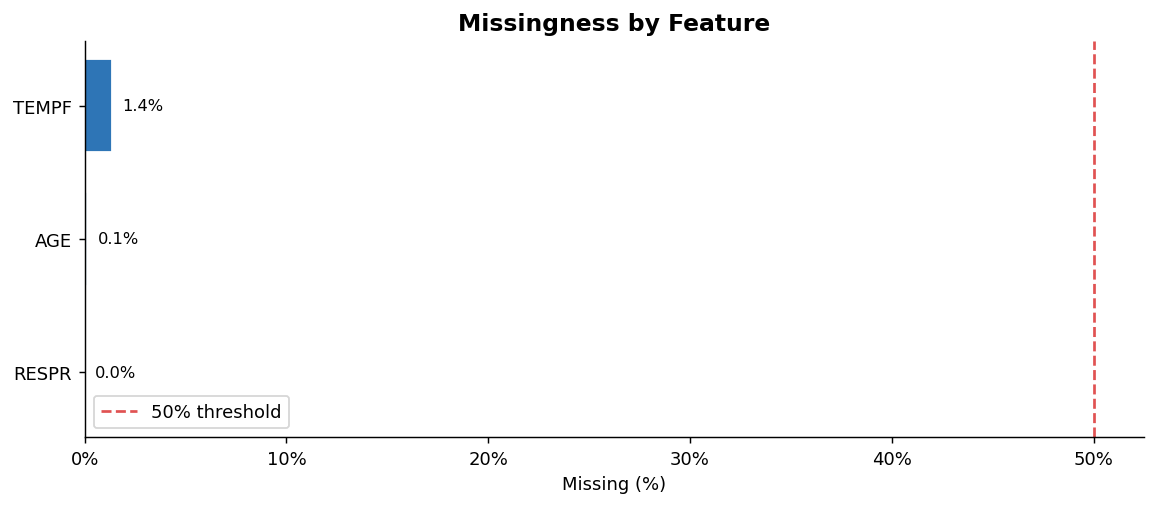

High missingness in vitals is expected — not all patients have all vitals recorded at triage.


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

miss = (X.isnull().sum() / len(X) * 100).sort_values(ascending=True)
miss = miss[miss > 0]

bars = ax.barh(miss.index, miss.values, color=PALETTE[1], edgecolor='white', height=0.7)
ax.axvline(50, color='#E05252', lw=1.5, linestyle='--', label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missingness by Feature')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

for bar, val in zip(bars, miss.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_01_missingness.png', bbox_inches='tight')
plt.show()
print("High missingness in vitals is expected — not all patients have all vitals recorded at triage.")


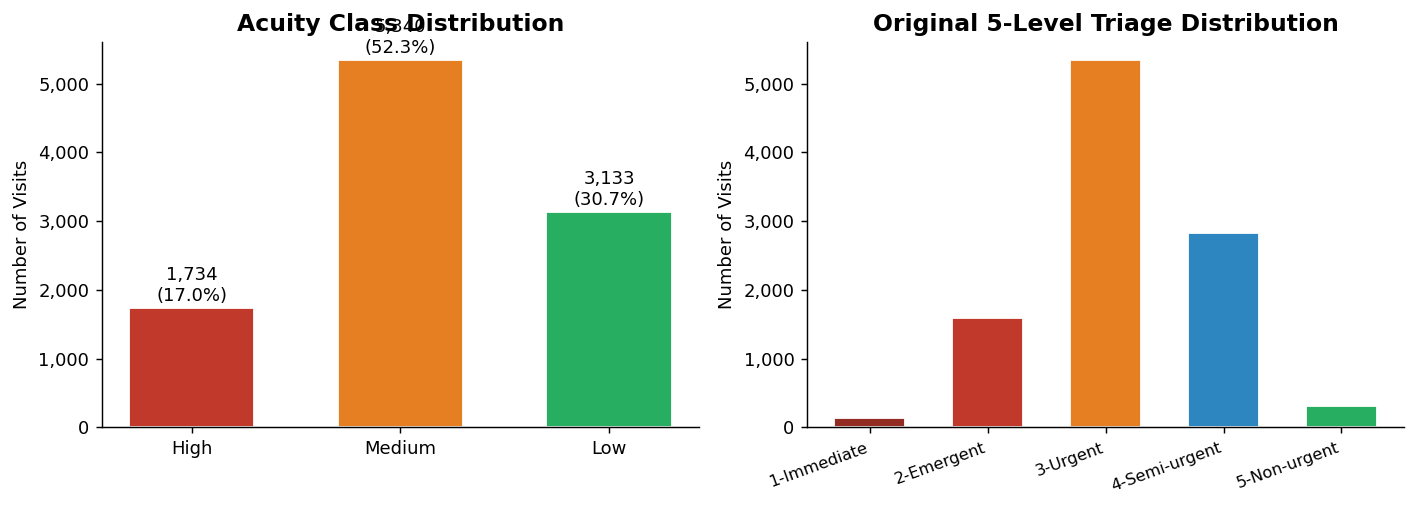

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
counts = df['ACUITY'].value_counts().reindex(['High', 'Medium', 'Low'])
colors = ['#C0392B', '#E67E22', '#27AE60']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Acuity Class Distribution')
axes[0].set_ylabel('Number of Visits')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

# Original 5-level breakdown
orig_counts = df['IMMEDR'].map({1:'1-Immediate', 2:'2-Emergent', 3:'3-Urgent',
                                 4:'4-Semi-urgent', 5:'5-Non-urgent'}).value_counts().sort_index()
orig_colors = ['#922B21', '#C0392B', '#E67E22', '#2E86C1', '#27AE60']
axes[1].bar(range(len(orig_counts)), orig_counts.values, color=orig_colors, edgecolor='white', width=0.6)
axes[1].set_xticks(range(len(orig_counts)))
axes[1].set_xticklabels(orig_counts.index, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Original 5-Level Triage Distribution')
axes[1].set_ylabel('Number of Visits')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot_02_class_distribution.png', bbox_inches='tight')
plt.show()


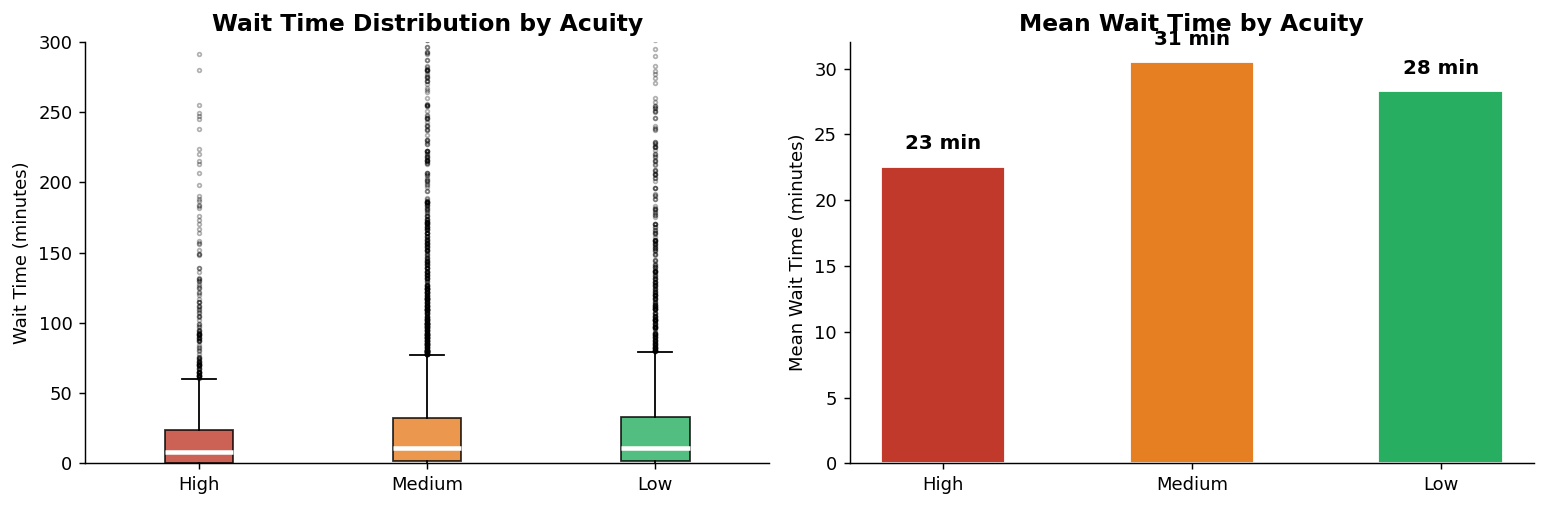


📊 Mean wait times by acuity:
ACUITY
High      22.5
Medium    30.5
Low       28.3


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
acuity_order = ['High', 'Medium', 'Low']
box_colors = ['#C0392B', '#E67E22', '#27AE60']
data_by_acuity = [df[df['ACUITY'] == a]['WAITTIME'].dropna() for a in acuity_order]

bp = axes[0].boxplot(data_by_acuity, labels=acuity_order, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_ylabel('Wait Time (minutes)')
axes[0].set_title('Wait Time Distribution by Acuity')
axes[0].set_ylim(0, 300)

# Mean wait time bar
means = df.groupby('ACUITY')['WAITTIME'].mean().reindex(acuity_order)
axes[1].bar(means.index, means.values, color=box_colors, edgecolor='white', width=0.5)
axes[1].set_ylabel('Mean Wait Time (minutes)')
axes[1].set_title('Mean Wait Time by Acuity')
for i, (idx, val) in enumerate(means.items()):
    axes[1].text(i, val + 1, f'{val:.0f} min', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_03_waittime.png', bbox_inches='tight')
plt.show()
print("\n📊 Mean wait times by acuity:")
print(means.round(1).to_string())


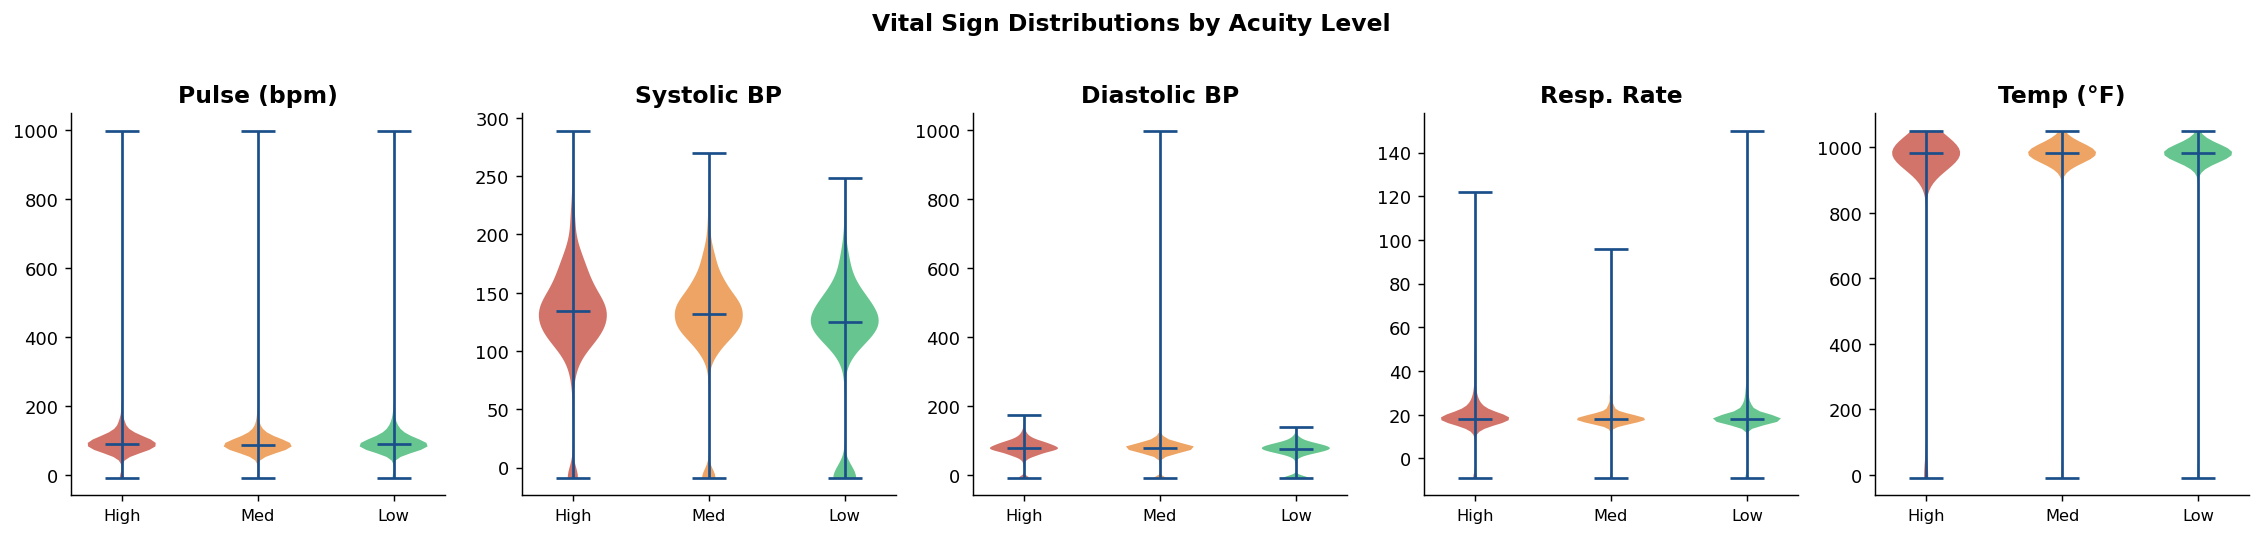

In [10]:
vital_cols = [c for c in ['PULSE', 'BPSYS', 'BPDIAS', 'RESPR', 'TEMPF'] if c in X.columns]
vital_labels = {'PULSE': 'Pulse (bpm)', 'BPSYS': 'Systolic BP', 'BPDIAS': 'Diastolic BP',
                'RESPR': 'Resp. Rate', 'TEMPF': 'Temp (°F)'}

n = len(vital_cols)
fig, axes = plt.subplots(1, n, figsize=(3.5*n, 4))
if n == 1: axes = [axes]

for ax, col in zip(axes, vital_cols):
    data = [df[df['ACUITY'] == a][col].dropna() for a in ['High', 'Medium', 'Low']]
    bp = ax.violinplot(data, positions=[0, 1, 2], showmedians=True)
    for i, (pc, color) in enumerate(zip(bp['bodies'], ['#C0392B', '#E67E22', '#27AE60'])):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['High', 'Med', 'Low'], fontsize=9)
    ax.set_title(vital_labels.get(col, col))

fig.suptitle('Vital Sign Distributions by Acuity Level', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_04_vitals.png', bbox_inches='tight')
plt.show()


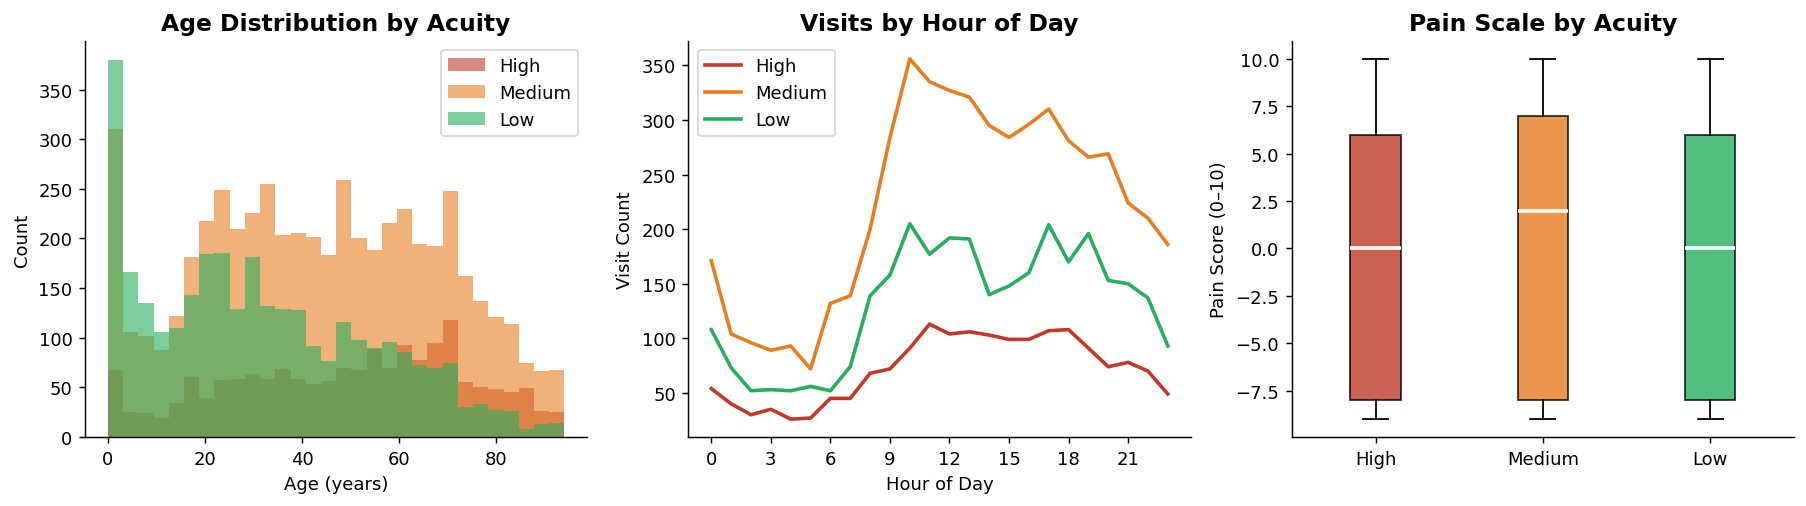

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age histogram by acuity
for acuity, color in zip(['High', 'Medium', 'Low'], ['#C0392B', '#E67E22', '#27AE60']):
    subset = df[df['ACUITY'] == acuity]['AGE'].dropna()
    axes[0].hist(subset, bins=30, alpha=0.6, label=acuity, color=color, edgecolor='none')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Acuity')
axes[0].legend()

# Arrival by hour
if 'ARRTIME' in df.columns:
    df['HOUR'] = (pd.to_numeric(df['ARRTIME'], errors='coerce') // 100).clip(0, 23)
    hourly = df.groupby(['HOUR', 'ACUITY']).size().unstack(fill_value=0)
    for acuity, color in zip(['High', 'Medium', 'Low'], ['#C0392B', '#E67E22', '#27AE60']):
        if acuity in hourly.columns:
            axes[1].plot(hourly.index, hourly[acuity], color=color, label=acuity, lw=2)
    axes[1].set_xlabel('Hour of Day')
    axes[1].set_ylabel('Visit Count')
    axes[1].set_title('Visits by Hour of Day')
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].legend()

# Pain scale by acuity
if 'PAINSCALE' in df.columns:
    pain_data = [df[df['ACUITY'] == a]['PAINSCALE'].dropna() for a in ['High', 'Medium', 'Low']]
    axes[2].boxplot(pain_data, labels=['High', 'Medium', 'Low'], patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(axes[2].findobj(plt.matplotlib.patches.PathPatch),
                             ['#C0392B', '#E67E22', '#27AE60']):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    axes[2].set_ylabel('Pain Score (0–10)')
    axes[2].set_title('Pain Scale by Acuity')

plt.tight_layout()
plt.savefig('plot_05_patterns.png', bbox_inches='tight')
plt.show()


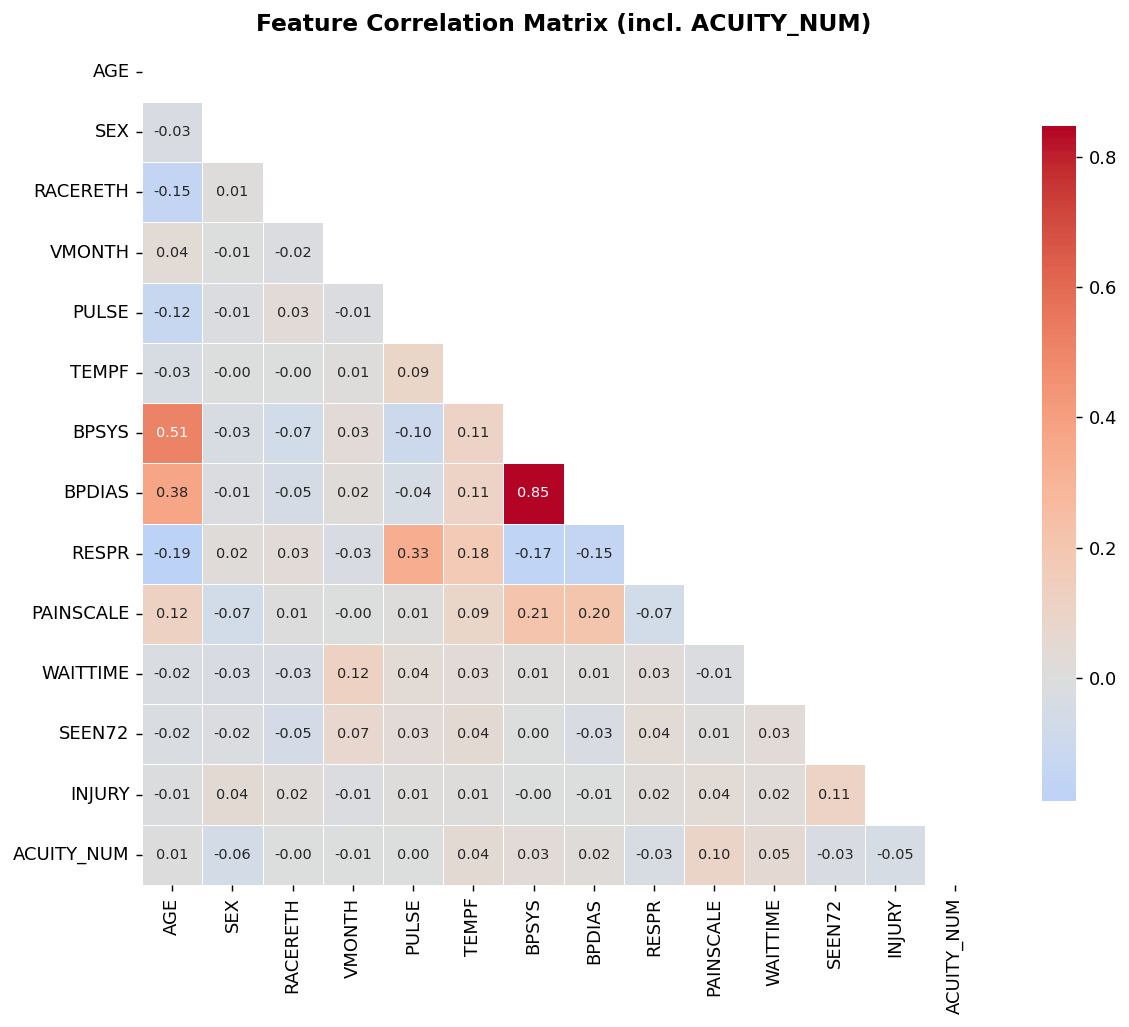


📊 Top feature correlations with acuity:
PAINSCALE    0.096
SEX          0.060
WAITTIME     0.047
INJURY       0.046
TEMPF        0.044
RESPR        0.034
BPSYS        0.029
SEEN72       0.026
BPDIAS       0.019
VMONTH       0.006


In [12]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
corr_df = df[numeric_cols + ['ACUITY']].copy()
corr_df['ACUITY_NUM'] = le.transform(df['ACUITY'])

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = corr_df[numeric_cols + ['ACUITY_NUM']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (incl. ACUITY_NUM)')
plt.tight_layout()
plt.savefig('plot_06_correlation.png', bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr_matrix['ACUITY_NUM'].drop('ACUITY_NUM').abs().sort_values(ascending=False)
print("\n📊 Top feature correlations with acuity:")
print(target_corr.head(10).round(3).to_string())


In [13]:
# ── Train/test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── Pipeline: impute → XGBoost ────────────────────────────────────────────────
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("\n✅ Model trained")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1:       {f1_score(y_test, y_pred, average='macro'):.4f}")
try:
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    print(f"Macro ROC-AUC:  {auc:.4f}")
except Exception as e:
    print(f"ROC-AUC: {e}")


Train: 8,165  |  Test: 2,042

✅ Model trained
Test Accuracy:  0.5573
Macro F1:       0.4595
Macro ROC-AUC:  0.6799


In [14]:
# ── Full classification report ────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))



Classification Report:
              precision    recall  f1-score   support

        High       0.57      0.19      0.29       347
         Low       0.49      0.38      0.43       627
      Medium       0.58      0.78      0.66      1068

    accuracy                           0.56      2042
   macro avg       0.55      0.45      0.46      2042
weighted avg       0.55      0.56      0.53      2042



In [15]:
# ── 5-fold cross-validation ───────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X, y_enc, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f"5-Fold CV Macro F1:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold scores:     {[f'{s:.4f}' for s in cv_scores]}")


5-Fold CV Macro F1:  0.4559 ± 0.0134
Per-fold scores:     ['0.4537', '0.4794', '0.4445', '0.4602', '0.4418']


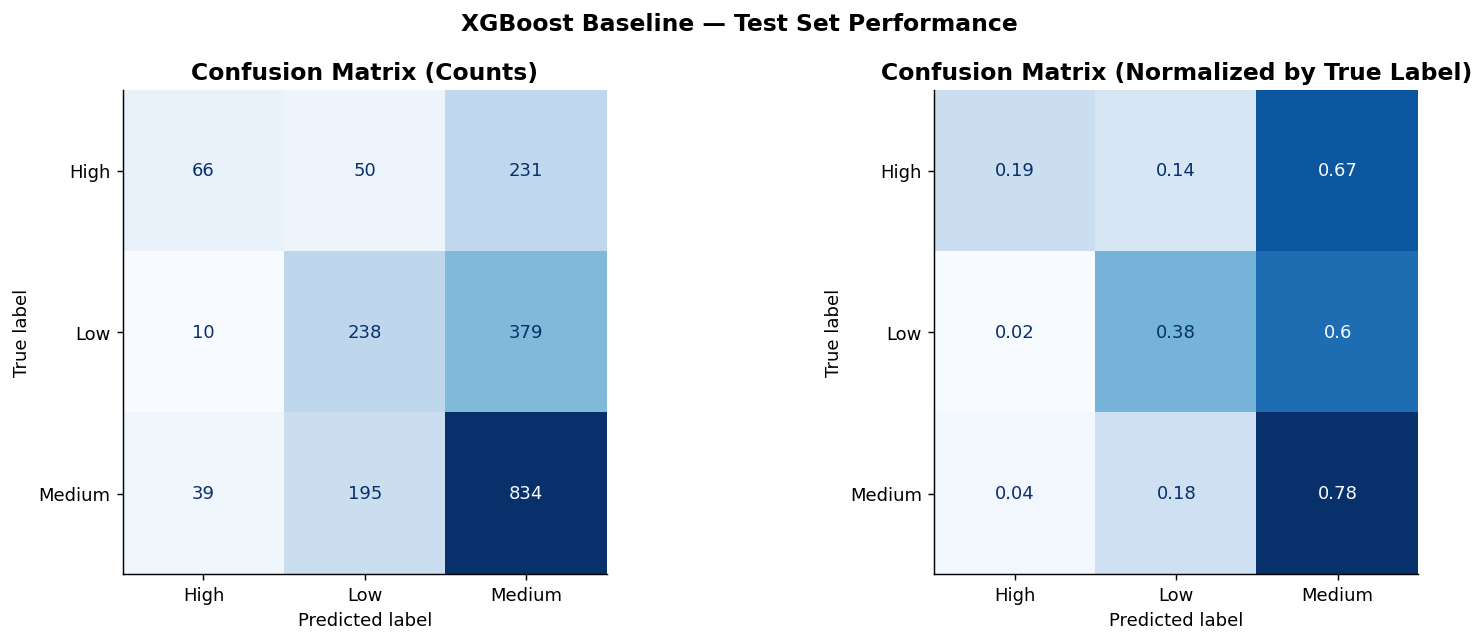

In [16]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized (row = true label)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=le.classes_)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Normalized by True Label)')

plt.suptitle('XGBoost Baseline — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_07_confusion_matrix.png', bbox_inches='tight')
plt.show()


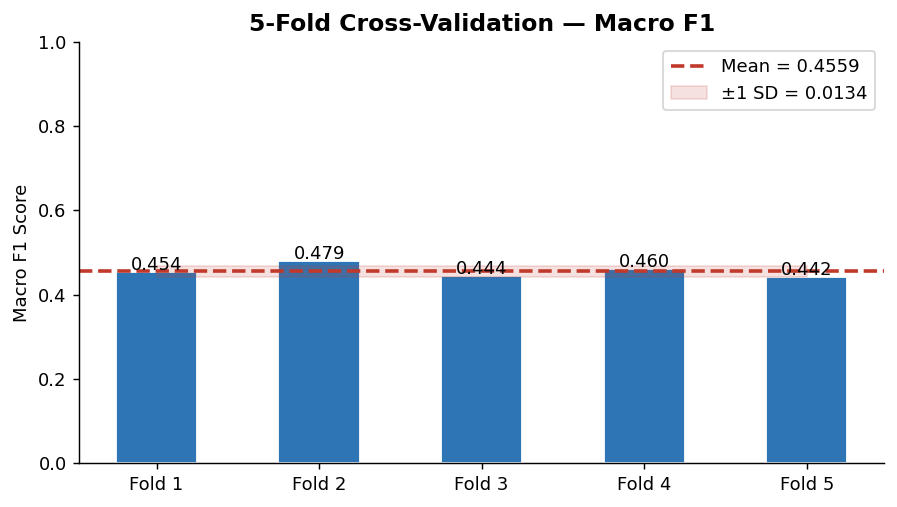

In [17]:
# ── Cross-validation scores plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

fold_nums = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars = ax.bar(fold_nums, cv_scores, color=PALETTE[1], edgecolor='white', width=0.5)
ax.axhline(cv_scores.mean(), color='#C0392B', lw=2, linestyle='--',
           label=f'Mean = {cv_scores.mean():.4f}')
ax.fill_between(range(len(cv_scores)),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color='#C0392B', label=f'±1 SD = {cv_scores.std():.4f}')
ax.set_ylim(0, 1)
ax.set_ylabel('Macro F1 Score')
ax.set_title('5-Fold Cross-Validation — Macro F1')
ax.legend()
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_08_cv_scores.png', bbox_inches='tight')
plt.show()


In [18]:
# ── Compute SHAP values ───────────────────────────────────────────────────────
imputer = model.named_steps['imputer']
clf = model.named_steps['clf']

X_test_imp = imputer.transform(X_test)
X_test_imp_df = pd.DataFrame(X_test_imp, columns=FEATURE_COLS)

explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test_imp_df)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"  → {shap_values.values.shape[0]} samples × {shap_values.values.shape[1]} features × {shap_values.values.shape[2]} classes")
print(f"  Classes: {list(le.classes_)}")


SHAP values shape: (2042, 14, 3)
  → 2042 samples × 14 features × 3 classes
  Classes: ['High', 'Low', 'Medium']


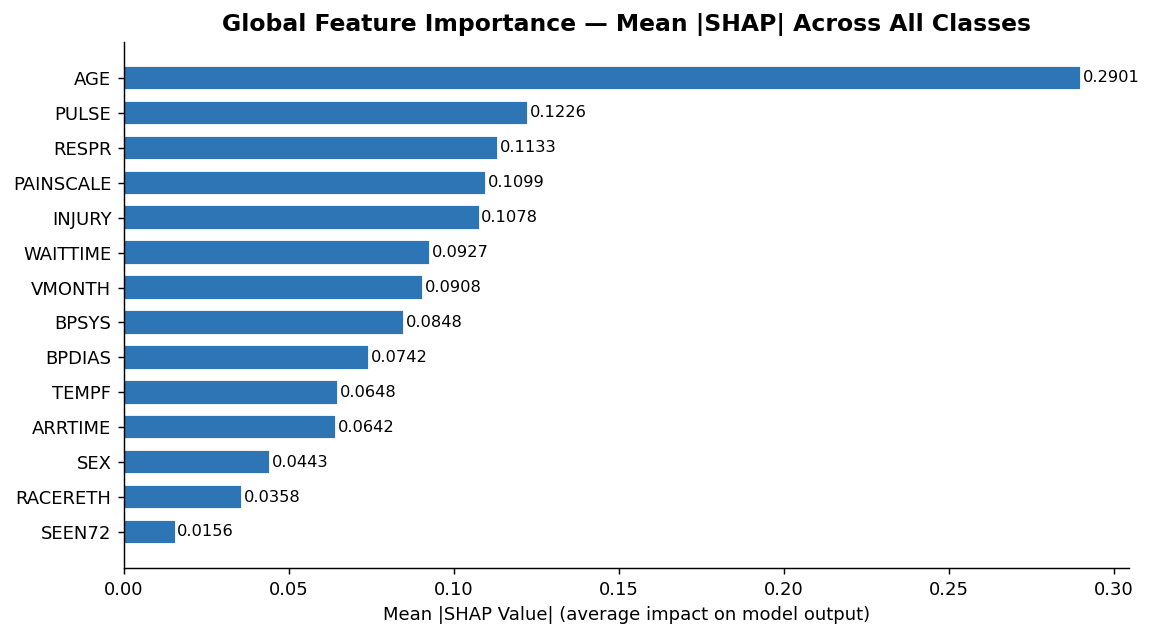


📊 Top 10 most influential features (global):
AGE          0.2901
PULSE        0.1226
RESPR        0.1133
PAINSCALE    0.1099
INJURY       0.1078
WAITTIME     0.0927
VMONTH       0.0908
BPSYS        0.0848
BPDIAS       0.0742
TEMPF        0.0648


In [19]:
# Mean absolute SHAP across all classes
mean_abs_shap = np.abs(shap_values.values).mean(axis=(0, 2))
shap_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(shap_importance.index[::-1], shap_importance.values[::-1],
               color=PALETTE[1], edgecolor='white', height=0.7)
ax.set_xlabel('Mean |SHAP Value| (average impact on model output)')
ax.set_title('Global Feature Importance — Mean |SHAP| Across All Classes')
for bar, val in zip(bars, shap_importance.values[::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_09_shap_global.png', bbox_inches='tight')
plt.show()

print("\n📊 Top 10 most influential features (global):")
print(shap_importance.head(10).round(4).to_string())


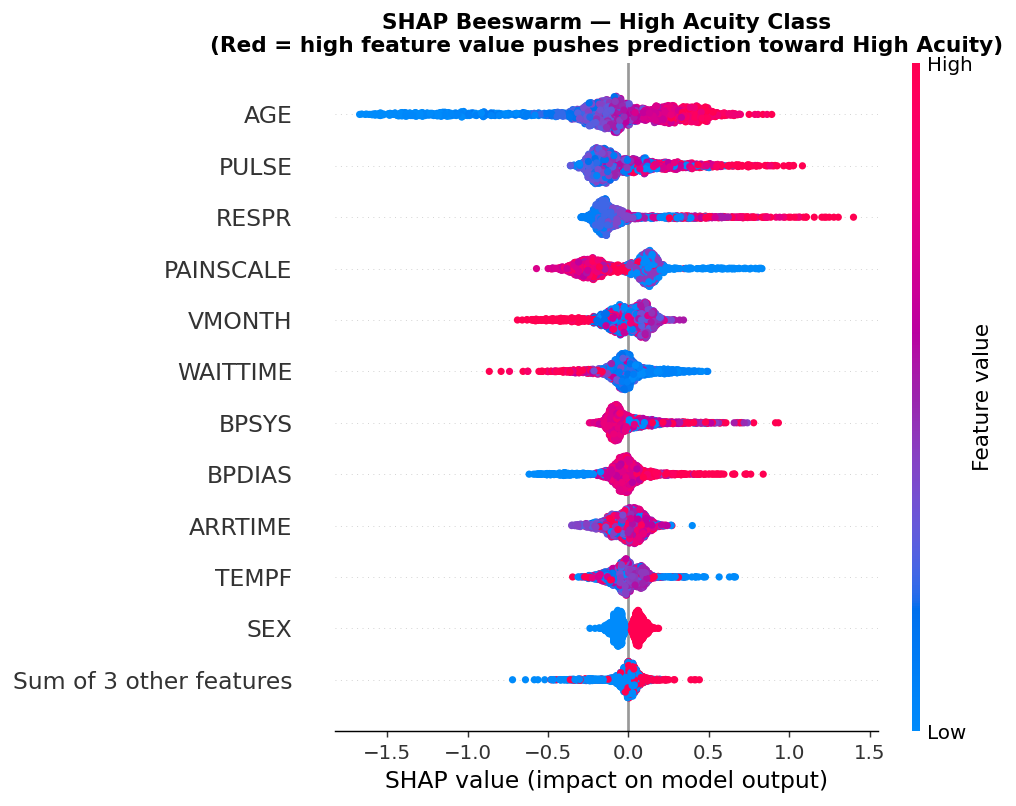

In [20]:
# Class index for 'High' acuity
high_idx = list(le.classes_).index('High')

fig = plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values[:, :, high_idx], max_display=12, show=False)
plt.title('SHAP Beeswarm — High Acuity Class\n(Red = high feature value pushes prediction toward High Acuity)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_10_shap_beeswarm_high.png', bbox_inches='tight')
plt.show()


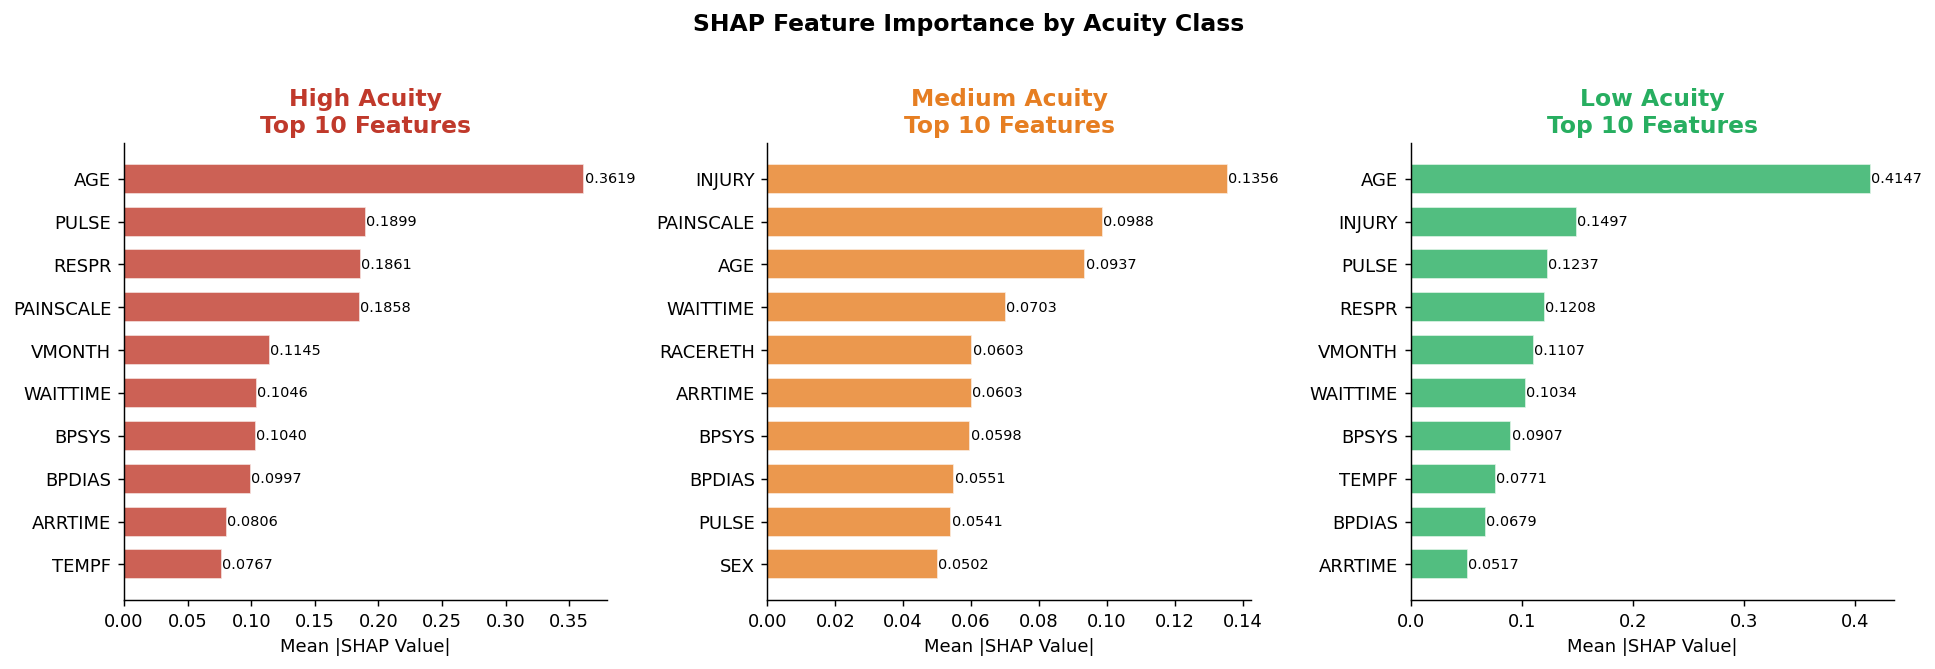

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
class_colors = {'High': '#C0392B', 'Medium': '#E67E22', 'Low': '#27AE60'}

for ax, (class_name, color) in zip(axes, class_colors.items()):
    class_idx = list(le.classes_).index(class_name)
    mean_shap = np.abs(shap_values[:, :, class_idx].values).mean(axis=0)
    importance = pd.Series(mean_shap, index=FEATURE_COLS).sort_values(ascending=True).tail(10)

    ax.barh(importance.index, importance.values, color=color, alpha=0.8, edgecolor='white', height=0.7)
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title(f'{class_name} Acuity\nTop 10 Features', color=color, fontweight='bold')
    for i, (feat, val) in enumerate(importance.items()):
        ax.text(val + 0.0001, i, f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('SHAP Feature Importance by Acuity Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_11_shap_per_class.png', bbox_inches='tight')
plt.show()


In [22]:
# Pick 5 representative test patients — one from each original triage level
np.random.seed(RANDOM_STATE)
sample_indices = []
for cls in range(len(le.classes_)):
    class_indices = np.where(y_test == cls)[0]
    if len(class_indices) > 0:
        sample_indices.append(np.random.choice(class_indices))

print(f"Selected {len(sample_indices)} sample patients for waterfall plots")
print(f"True acuity labels: {[le.classes_[y_test[i]] for i in sample_indices]}")


Selected 3 sample patients for waterfall plots
True acuity labels: ['High', 'Low', 'Medium']


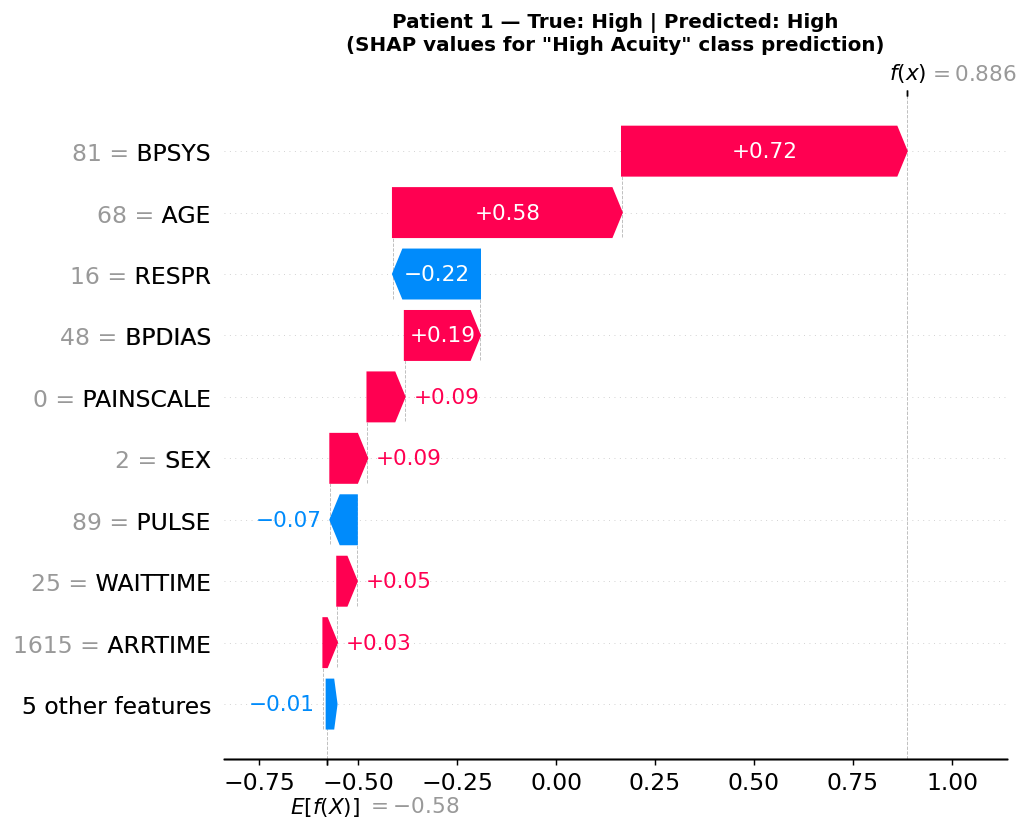

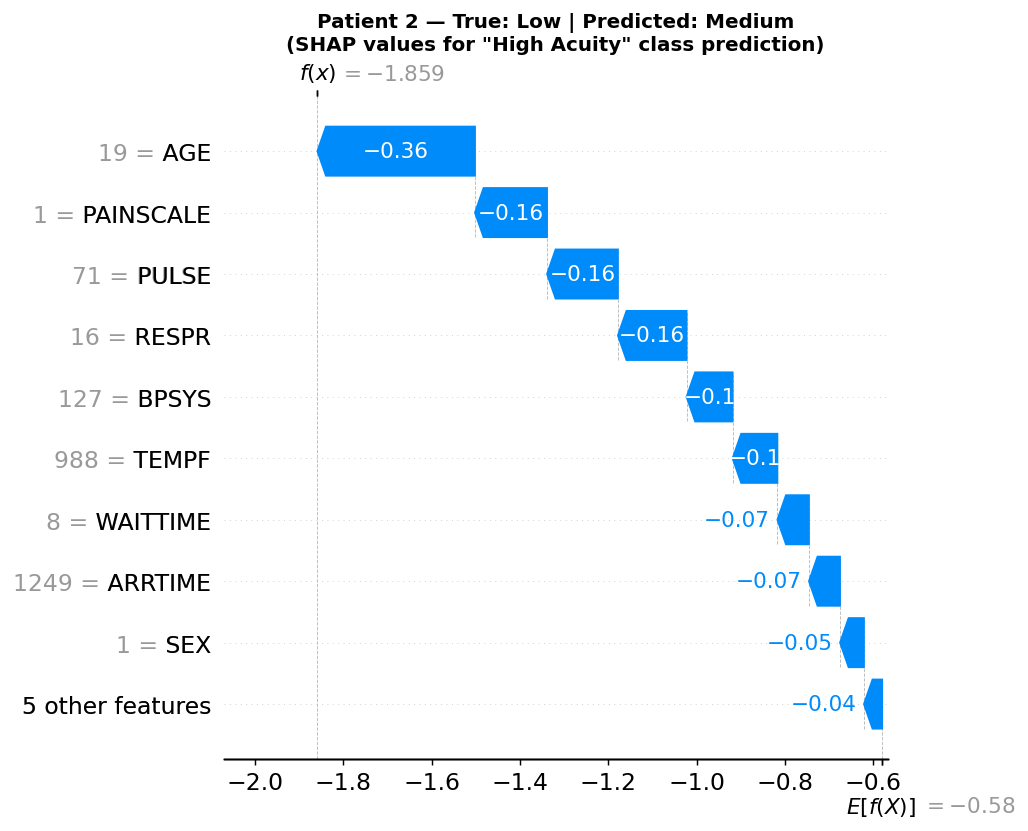

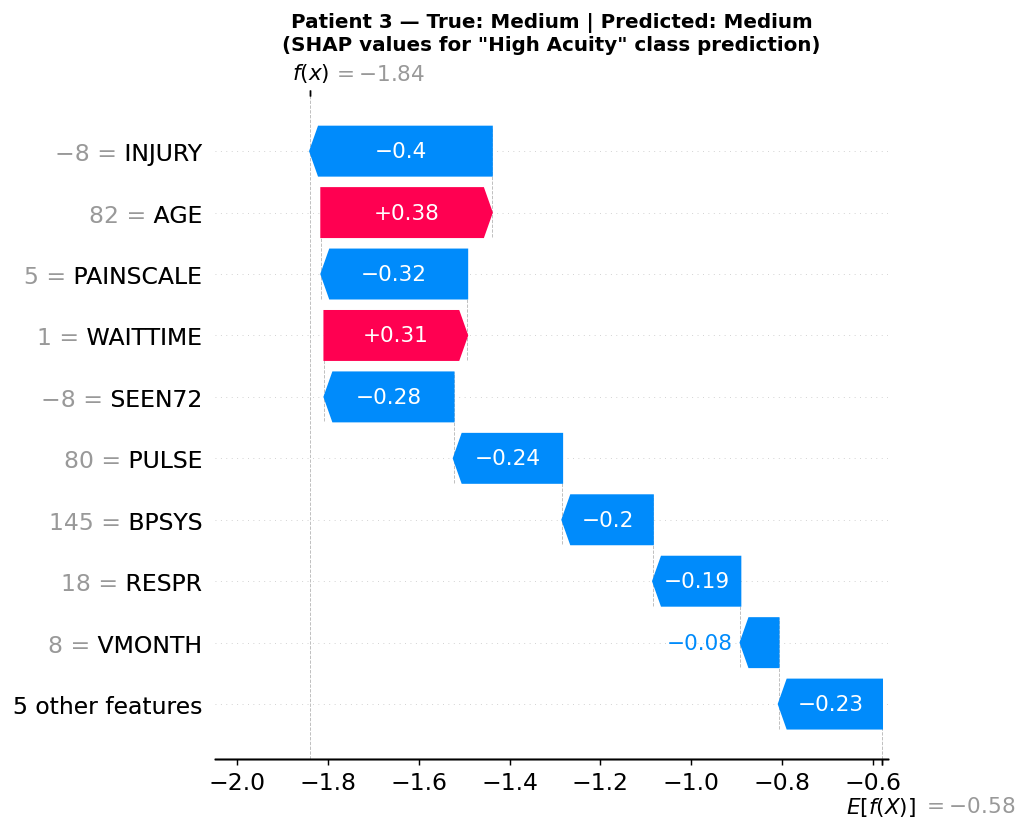

In [23]:
for i, idx in enumerate(sample_indices):
    true_label = le.classes_[y_test[idx]]
    pred_label = le.classes_[y_pred[idx]]
    high_idx = list(le.classes_).index('High')

    fig = plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_values[idx, :, high_idx], max_display=10, show=False)
    plt.title(f'Patient {i+1} — True: {true_label} | Predicted: {pred_label}\n'
              f'(SHAP values for "High Acuity" class prediction)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plot_12_waterfall_patient{i+1}.png', bbox_inches='tight')
    plt.show()


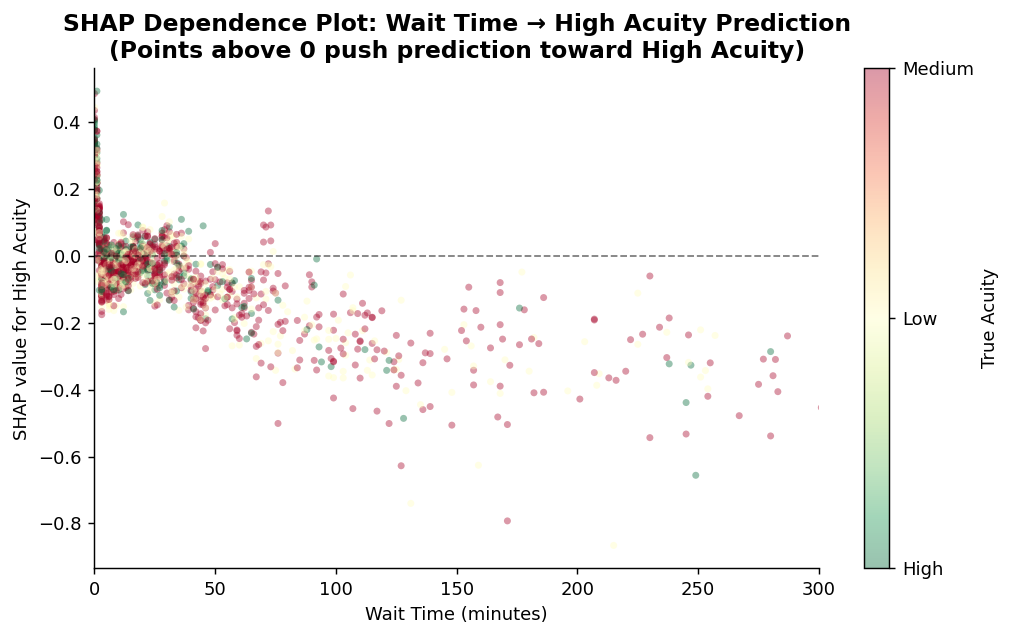

In [24]:
if 'WAITTIME' in FEATURE_COLS:
    high_idx = list(le.classes_).index('High')
    feat_idx = FEATURE_COLS.index('WAITTIME')

    fig, ax = plt.subplots(figsize=(8, 5))
    wait_vals = X_test_imp_df['WAITTIME'].values
    shap_wait = shap_values[:, feat_idx, high_idx].values

    # Color by acuity
    scatter = ax.scatter(wait_vals, shap_wait, c=y_test, cmap='RdYlGn_r',
                         alpha=0.4, s=15, edgecolors='none')
    ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
    ax.set_xlabel('Wait Time (minutes)')
    ax.set_ylabel('SHAP value for High Acuity')
    ax.set_title('SHAP Dependence Plot: Wait Time → High Acuity Prediction\n'
                 '(Points above 0 push prediction toward High Acuity)')
    ax.set_xlim(0, 300)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_ticks([0, 1, 2])
    cbar.set_ticklabels(le.classes_)
    cbar.set_label('True Acuity')

    plt.tight_layout()
    plt.savefig('plot_13_shap_dependence_waittime.png', bbox_inches='tight')
    plt.show()
